In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

In [ ]:
data = pd.read_csv("HR_Job_Placement_Dataset.csv")
data.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,...,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,...,10.807739,Tier 1,Matched,High,Required,0.0,NaN,NaN,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,...,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,...,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,NaN,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,...,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed


In [3]:
data.columns

Index(['age_years', 'gender', 'ssc_percentage', 'hsc_percentage',
       'degree_percentage', 'degree_specialization', 'technical_score',
       'aptitude_score', 'communication_score', 'skills_match_percentage',
       'certifications_count', 'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'company_tier', 'job_role_match',
       'competition_level', 'bond_requirement', 'notice_period_days',
       'layoff_history', 'employment_gap_months', 'relocation_willingness',
       'status'],
      dtype='object')

In [4]:
data.shape

(51500, 26)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  object 
 2   ssc_percentage             48919 non-null  float64
 3   hsc_percentage             49435 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  object 
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  object 
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  43034 non-null  obj

In [6]:
data.isnull().sum()

age_years                       0
gender                          0
ssc_percentage               2581
hsc_percentage               2065
degree_percentage               0
degree_specialization           0
technical_score                 0
aptitude_score                  0
communication_score             0
skills_match_percentage         0
certifications_count            0
internship_experience           0
years_of_experience             0
career_switch_willingness    8466
relevant_experience          8426
previous_ctc_lpa                0
expected_ctc_lpa                0
company_tier                    0
job_role_match               6131
competition_level               0
bond_requirement                0
notice_period_days           1582
layoff_history               8467
employment_gap_months        1097
relocation_willingness       8475
status                          0
dtype: int64

In [7]:
(data.isnull().sum()/len(data))*100


age_years                     0.000000
gender                        0.000000
ssc_percentage                5.011650
hsc_percentage                4.009709
degree_percentage             0.000000
degree_specialization         0.000000
technical_score               0.000000
aptitude_score                0.000000
communication_score           0.000000
skills_match_percentage       0.000000
certifications_count          0.000000
internship_experience         0.000000
years_of_experience           0.000000
career_switch_willingness    16.438835
relevant_experience          16.361165
previous_ctc_lpa              0.000000
expected_ctc_lpa              0.000000
company_tier                  0.000000
job_role_match               11.904854
competition_level             0.000000
bond_requirement              0.000000
notice_period_days            3.071845
layoff_history               16.440777
employment_gap_months         2.130097
relocation_willingness       16.456311
status                   

In [8]:
data.describe()


,age_years,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,years_of_experience,previous_ctc_lpa,expected_ctc_lpa,notice_period_days,employment_gap_months
count,51500.000000,48919.000000,49435.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,51500.000000,49918.000000,50403.000000
mean,27.505456,70.002505,72.060636,74.010825,68.027499,64.005715,66.106692,73.937491,1.400136,1.494117,4.844616,8.002649,20.095457,3.056187
std,4.025385,7.976314,7.916654,6.945579,11.855145,9.922397,9.907488,11.794258,1.184387,1.375508,2.125294,3.133792,24.852660,4.431784
min,21.000000,50.000000,50.000000,55.000000,40.000000,40.000000,45.000000,45.000000,0.000000,0.000000,1.000000,3.000000,0.000000,0.000000
25%,24.000000,64.574733,66.720058,69.305041,59.935988,57.204237,59.252271,65.851924,1.000000,0.000000,3.325635,5.672655,0.000000,0.000000
50%,27.000000,69.971210,72.014383,73.998187,67.986042,63.972079,66.033268,74.001772,1.000000,1.000000,4.807598,7.857337,15.000000,0.000000
75%,31.000000,75.389057,77.389894,78.707827,76.049235,70.727134,72.840985,82.112773,2.000000,2.000000,6.297570,10.093509,30.000000,6.000000
max,34.000000,95.000000,95.000000,95.000000,100.000000,100.000000,100.000000,100.000000,8.000000,5.000000,13.844566,26.524634,90.000000,18.000000


In [9]:
data.duplicated().sum()


np.int64(1376)

In [10]:
data[data.duplicated()]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
50000,29,Male,82.777504,55.403494,72.608382,Computer Science,85.730203,72.426358,51.770110,97.577679,...,9.093150,Tier 2,Matched,Medium,Not Required,15.0,No,0.0,Not Willing,Placed
50001,27,male,54.905068,80.120543,77.037600,Computer Science,54.166158,61.548708,65.307474,66.014409,...,7.292962,Tier 2,Matched,Low,Not Required,15.0,No,0.0,NaN,Not Placed
50003,21,Female,62.638945,60.735432,77.153040,Computer Science,59.987920,59.017158,56.717055,73.084570,...,7.108719,Tier 1,Matched,Low,Not Required,0.0,No,0.0,Not Willing,Not Placed
50004,25,Male,59.360622,70.230456,85.377955,Mechanical,65.678132,83.774928,79.334052,80.443948,...,10.555169,Tier 1,Matched,Low,Required,60.0,No,0.0,Not Willing,Not Placed
50005,22,Female,72.019465,79.009356,67.887885,Others,56.213118,73.397254,48.806828,91.301263,...,7.938697,Tier 1,Matched,Low,Not Required,60.0,No,12.0,Willing,Not Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51494,26,Female,69.562323,63.891266,75.931809,Computer Science,59.990409,51.169120,73.769113,68.913006,...,7.910303,Tier 2,NaN,Medium,Not Required,0.0,No,6.0,Not Willing,Not Placed
51495,24,Female,65.747180,72.063946,72.247881,Electronics,55.923057,73.208032,69.108895,63.992488,...,6.315211,Tier 1,Matched,Low,Required,0.0,No,3.0,NaN,Not Placed
51496,22,Male,61.921459,66.729203,55.000000,Others,69.525121,70.245612,54.959868,88.514232,...,8.655391,Tier 1,Matched,Medium,Not Required,60.0,No,0.0,Not Willing,Placed
51498,29,Female,77.327209,56.629227,69.735374,Mechanical,48.270078,61.171900,71.650243,76.318681,...,9.617279,Tier 2,Matched,Medium,Not Required,0.0,Yes,0.0,Willing,Not Placed


In [11]:
data = data.drop_duplicates()


In [12]:
#duplicated checks
print(data.duplicated().sum())
print("-----------------------")
#identify dupilcated rows
data[data.duplicated()].head()

0
-----------------------


,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status


In [13]:
cat_col = data.select_dtypes(include=['object','category']).columns
cat_col

Index(['gender', 'degree_specialization', 'internship_experience',
       'career_switch_willingness', 'relevant_experience', 'company_tier',
       'job_role_match', 'competition_level', 'bond_requirement',
       'layoff_history', 'relocation_willingness', 'status'],
      dtype='object')

In [14]:
num_col = data.select_dtypes(include=['float64','int64']).columns
num_col

Index(['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage',
       'technical_score', 'aptitude_score', 'communication_score',
       'skills_match_percentage', 'certifications_count',
       'years_of_experience', 'previous_ctc_lpa', 'expected_ctc_lpa',
       'notice_period_days', 'employment_gap_months'],
      dtype='object')

In [15]:
#check invalid categories logical inconsistency
#numerical invalid
#age
data[(data['age_years'] < 18) | (data['age_years']> 60)]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status


In [16]:
#percentage
data[(data['ssc_percentage'] < 0) |(data['ssc_percentage']> 100)]
data[(data['hsc_percentage'] < 0)|(data['hsc_percentage'] > 100)]
data[(data['degree_percentage'] < 0)|(data['degree_percentage']> 100)]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status


In [17]:
#scores
data[(data['technical_score'] < 0)|(data['technical_score'] > 100)]
data[(data['aptitude_score'] < 0)|(data['aptitude_score'] > 100)]
data[(data['communication_score'] < 0)|(data['communication_score'] > 100)]
data[(data['skills_match_percentage'] < 0)|(data['skills_match_percentage'] > 100)]


,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status


In [18]:
#counts
data[(data['certifications_count'] < 0)]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status


In [19]:
#experience
data[(data['years_of_experience'] < 0)|(data['years_of_experience']>40)]


,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status


In [20]:
#salary details & discuss
data[(data['previous_ctc_lpa'] < 0)]
data[(data['expected_ctc_lpa'] < 0)]

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status


In [21]:
#notice period
data[(data['notice_period_days'] < 0)|(data['notice_period_days']>365)]


,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status


In [22]:
#employment gap details
data[(data['employment_gap_months'] < 0)|(data['employment_gap_months']>120)]


,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status


In [23]:
#clean spaces & convert into lower case
for col in cat_col:
    print(f"\n{col}")
    print(data[col].astype(str).str.strip().value_counts(dropna=False))


gender
gender
Female    23701
Male      23416
female     1504
male       1503
Name: count, dtype: int64

degree_specialization
degree_specialization
Others                    10174
Electronics               10078
Information Technology    10032
Computer Science           9927
Mechanical                 9913
Name: count, dtype: int64

internship_experience
internship_experience
No     24902
Yes    22715
no      1314
yes     1193
Name: count, dtype: int64

career_switch_willingness
career_switch_willingness
Not Willing    27707
Willing        14175
nan             8242
Name: count, dtype: int64

relevant_experience
relevant_experience
Relevant        25597
Not Relevant    16328
nan              8199
Name: count, dtype: int64

company_tier
company_tier
Tier 1    19358
Tier 2    18534
Tier 3    12232
Name: count, dtype: int64

job_role_match
job_role_match
Matched        32557
Not Matched    11603
nan             5964
Name: count, dtype: int64

competition_level
competition_level
Low     

In [24]:
#categorical invalid - predefined
valid_values = {
    'gender' : ['male','female','nan'],
    'degree_specialization' : ['computer science', 'electronics', 'information technology','mechanical', 'others','nan'],
    'internship_experience' : ['yes','no','nan'],
    'career_switch_willingness' : ['yes','no','nan'],
    'relevant_experience' : ['relevant','not relevant','nan'],
    'company_tier' : ['tier 1', 'tier 2', 'tier 3','nan'],
    'job_role_match' : ['not matched', 'matched','nan'],
    'competition_level' : ['low','medium', 'high'],
    'bond_requirement' : ['not required', 'required'],
    'layoff_history' : ['yes', 'no','nan'],
    'relocation_willingness' : ['willing', 'not willing','nan'],
    'status': ['not placed', 'placed']
}

In [25]:
#clean +lowercase
for col in cat_col:
    data[col] = data[col].astype(str).str.strip().str.lower()

In [26]:
#standardize the categorical
for col, valid in valid_values.items():
    data[col] = data[col].replace({v.lower(): v for v in valid})


In [27]:
#check invalid categories
for col, valid in valid_values.items():
    print(f"\nInvalid values in {col}:")
    print(data[~data[col].isin(valid) & data[col].notna()][col].value_counts())



Invalid values in gender:
Series([], Name: count, dtype: int64)

Invalid values in degree_specialization:
Series([], Name: count, dtype: int64)

Invalid values in internship_experience:
Series([], Name: count, dtype: int64)

Invalid values in career_switch_willingness:
career_switch_willingness
not willing    27707
willing        14175
Name: count, dtype: int64

Invalid values in relevant_experience:
Series([], Name: count, dtype: int64)

Invalid values in company_tier:
Series([], Name: count, dtype: int64)

Invalid values in job_role_match:
Series([], Name: count, dtype: int64)

Invalid values in competition_level:
Series([], Name: count, dtype: int64)

Invalid values in bond_requirement:
Series([], Name: count, dtype: int64)

Invalid values in layoff_history:
Series([], Name: count, dtype: int64)

Invalid values in relocation_willingness:
Series([], Name: count, dtype: int64)

Invalid values in status:
Series([], Name: count, dtype: int64)


In [28]:
#handling missing values
#numnerical
data['ssc_percentage'].fillna(data['ssc_percentage'].median(),inplace = True)
data['hsc_percentage'].fillna(data['hsc_percentage'].median(),inplace = True)
data['notice_period_days'].fillna(0, inplace=True)
data['employment_gap_months'].fillna(0, inplace=True)


In [29]:
#categorical
for col in cat_col:
    data[col].fillna(data[col].mode()[0], inplace=True)

In [30]:
data[num_col].skew()


age_years                 -0.000771
ssc_percentage             0.051807
hsc_percentage             0.006765
degree_percentage          0.023309
technical_score            0.033090
aptitude_score             0.055237
communication_score        0.102680
skills_match_percentage   -0.046923
certifications_count       0.853062
years_of_experience        0.708221
previous_ctc_lpa           0.196384
expected_ctc_lpa           0.426532
notice_period_days         1.390284
employment_gap_months      1.751720
dtype: float64

In [31]:
#OUTLIER HANDLING
outlier_cols = [
    'employment_gap_months',
    'notice_period_days',
    'certifications_count',
    'years_of_experience'
]
for col in outlier_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    data[col] = np.where(data[col] > upper, upper, data[col])
    data[col] = np.where(data[col] < lower, lower, data[col])

    print(f"{col} → {len(outlier_cols)} outliers ({len(outlier_cols)/len(data)*100:.2f}%)")


employment_gap_months → 4 outliers (0.01%)
notice_period_days → 4 outliers (0.01%)
certifications_count → 4 outliers (0.01%)
years_of_experience → 4 outliers (0.01%)


In [32]:
print('Final_Missing_Values:\n',data.isnull().sum())


Final_Missing_Values:
 age_years                    0
gender                       0
ssc_percentage               0
hsc_percentage               0
degree_percentage            0
degree_specialization        0
technical_score              0
aptitude_score               0
communication_score          0
skills_match_percentage      0
certifications_count         0
internship_experience        0
years_of_experience          0
career_switch_willingness    0
relevant_experience          0
previous_ctc_lpa             0
expected_ctc_lpa             0
company_tier                 0
job_role_match               0
competition_level            0
bond_requirement             0
notice_period_days           0
layoff_history               0
employment_gap_months        0
relocation_willingness       0
status                       0
dtype: int64


In [33]:
print('\n Final_shape:',data.shape)



 Final_shape: (50124, 26)


In [34]:
clean_data = data.to_csv('job_acceptance_clean_Data.csv',index = False)


In [ ]:
dataa = pd.read_csv("job_acceptance_clean_Data.csv")
dataa.head()


,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,male,65.061656,83.842578,75.856526,computer science,58.221909,89.566305,64.474484,79.548913,...,5.805850,tier 3,not matched,medium,not required,15.0,no,15.0,not willing,not placed
1,24,male,67.885626,64.973305,73.093588,electronics,71.927978,54.591971,61.077306,73.316134,...,10.807739,tier 1,matched,high,required,0.0,NaN,0.0,not willing,not placed
2,33,female,73.892471,68.834121,90.196460,information technology,72.445041,58.587088,79.494739,75.466980,...,5.476839,tier 3,not matched,low,not required,0.0,no,3.0,not willing,placed
3,31,male,74.145568,76.255126,75.586731,mechanical,78.855676,61.022065,53.740386,73.676449,...,9.980580,tier 2,matched,low,not required,0.0,yes,6.0,NaN,not placed
4,28,male,60.475937,65.786336,80.801010,information technology,68.286776,65.713731,61.438314,88.994847,...,8.921233,tier 2,matched,medium,not required,0.0,no,3.0,willing,not placed


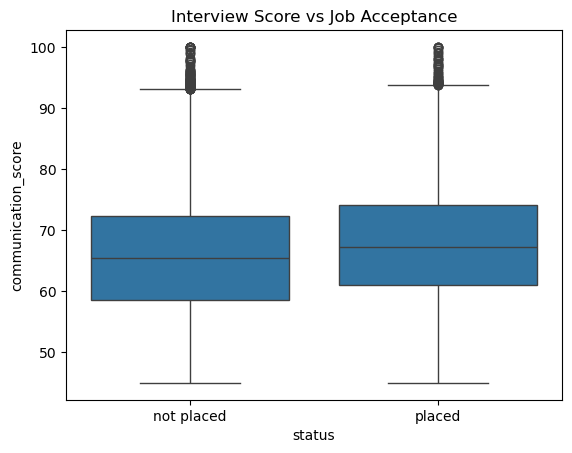

In [36]:
#Data visualization
#Interview score vs job acceptance
sns.boxplot(x='status', y='communication_score', data=dataa)
plt.title("Interview Score vs Job Acceptance")
plt.show()

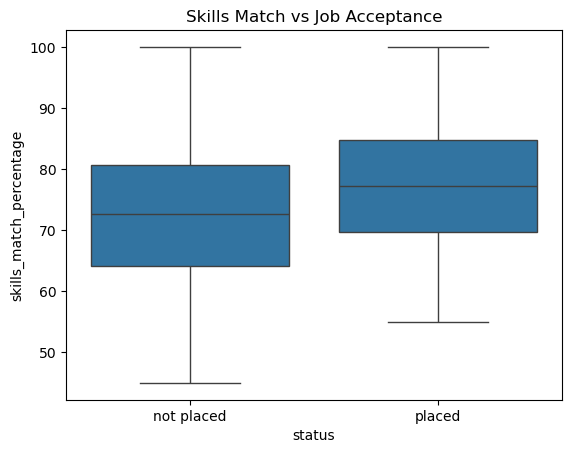

In [37]:
#Skills match percentage impact on placement
sns.boxplot(x='status', y='skills_match_percentage', data=dataa)
plt.title("Skills Match vs Job Acceptance")
plt.show()

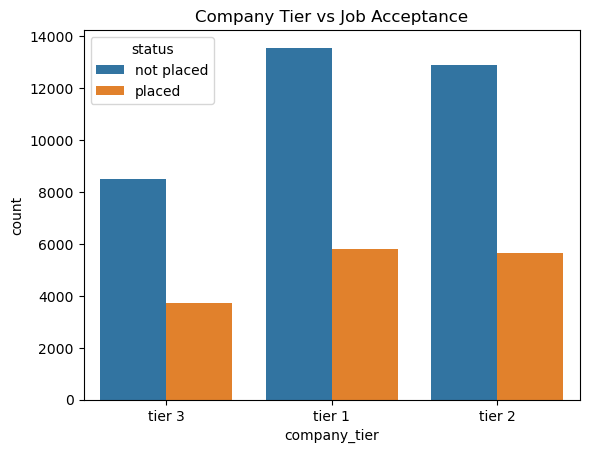

In [38]:
#Company tier vs acceptance rate
sns.countplot(x='company_tier', hue='status', data=dataa)
plt.title("Company Tier vs Job Acceptance")
plt.show()

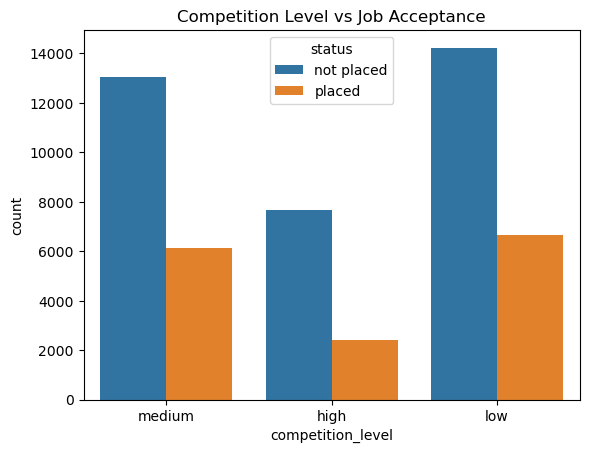

In [39]:
#Competition level vs job acceptance
sns.countplot(x='competition_level', hue='status', data=dataa)
plt.title("Competition Level vs Job Acceptance")
plt.show()


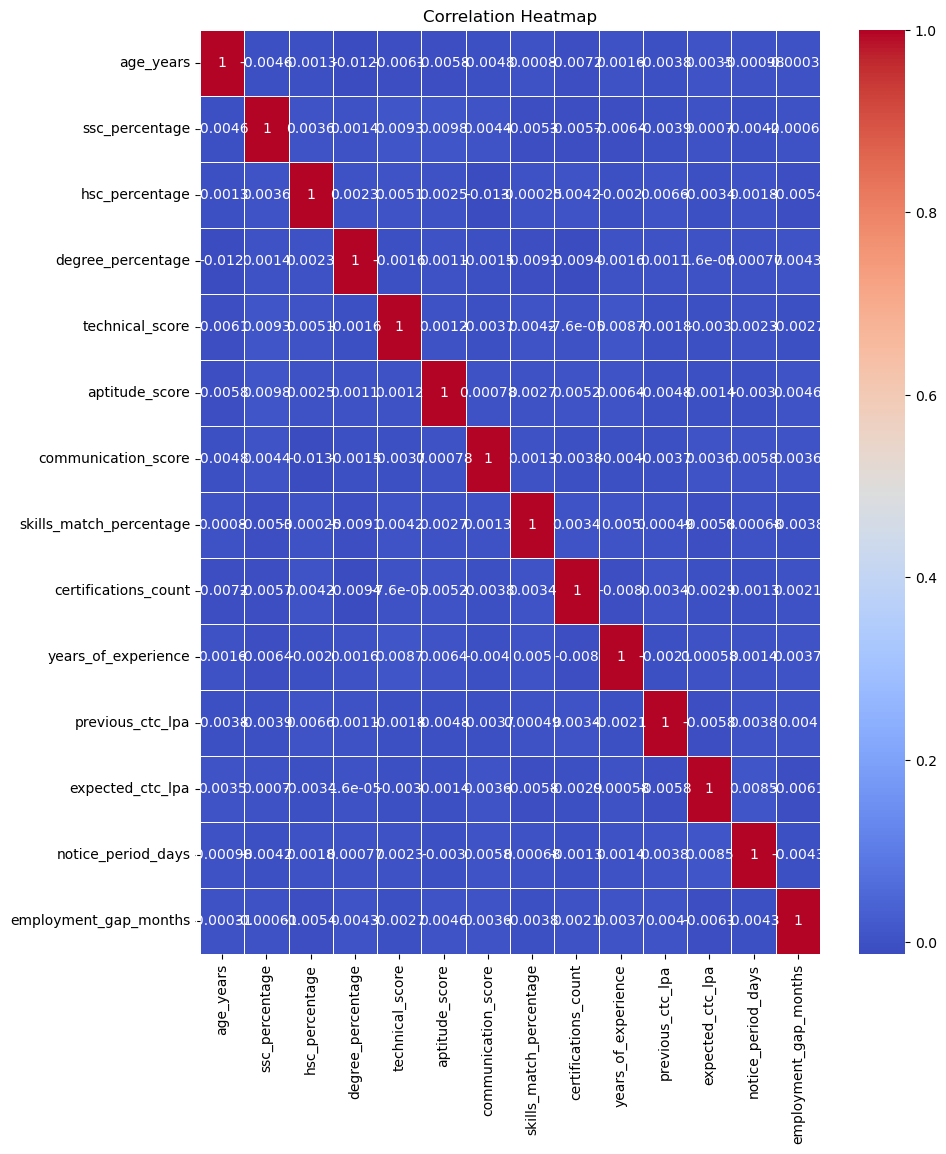

In [40]:
#HEATMAP CORRELATION
plt.figure(figsize=(10,12))
sns.heatmap(dataa[num_col].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

In [41]:
#FEATURE ENGINEERING
dataa['experience_level'] = dataa['years_of_experience'].apply(lambda x:'fresher' if x== 0 else('junior' if x<=3 else 'senior'))
dataa['academic_performance'] = dataa['degree_percentage'].apply(lambda x:'low' if x<60 else('medium' if x<75 else 'high'))
dataa['skills_level'] = dataa['skills_match_percentage'].apply(lambda x:'low' if x < 40 else ('medium' if x<70 else'high'))
dataa['interview_score'] = (dataa['technical_score'] +dataa['aptitude_score']+ dataa['communication_score'])/3
dataa['interview_category'] = dataa['interview_score'].apply(lambda x:'poor' if x < 50 else ('average' if x< 70 else 'good'))
dataa['placement_score'] = (0.25 *dataa['skills_match_percentage'] +
                            0.25 * dataa['technical_score'] +
                            0.25 * dataa['aptitude_score'] +
                            0.25 * dataa['communication_score'])
dataa['avg_score'] = ((dataa['technical_score'] + dataa['aptitude_score'] + dataa['communication_score']) / 3)
dataa['gap_category'] = dataa['employment_gap_months'].apply(lambda x: 'no gap' if x == 0 else 'has gap')


In [42]:
#ENCODING
dataa = pd.get_dummies(dataa, columns=['gender', 'degree_specialization', 'internship_experience',
       'career_switch_willingness', 'relevant_experience', 'company_tier',
       'job_role_match', 'competition_level', 'bond_requirement',
       'layoff_history', 'relocation_willingness','experience_level', 'academic_performance', 'skills_level',
       'interview_category', 'gap_category'], drop_first=True)


In [43]:
dataa['status'].isnull().sum()


np.int64(0)

In [44]:
#Supervised Machine Learning (Classification)
y = dataa['status']
x = dataa.drop('status', axis=1)


In [45]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [46]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000,class_weight='balanced'))
])


In [47]:
scaler = StandardScaler()


In [48]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state = 42)


In [49]:
x_train[num_col] = scaler.fit_transform(x_train[num_col])
x_test[num_col] = scaler.transform(x_test[num_col])

In [50]:
pipeline.fit(x_train,y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [51]:
y_prob = pipeline.predict_proba(x_test)[:,1]
y_pred = (y_prob > 0.45).astype(int)


In [52]:
#prediction
y_pred = pipeline.predict(x_test)

In [53]:
#evaluation
print("Logistic Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Logistic Accuracy: 0.8622443890274314

Confusion Matrix:
 [[6056  977]
 [ 404 2588]]

Classification Report:
               precision    recall  f1-score   support

  not placed       0.94      0.86      0.90      7033
      placed       0.73      0.86      0.79      2992

    accuracy                           0.86     10025
   macro avg       0.83      0.86      0.84     10025
weighted avg       0.87      0.86      0.87     10025



In [54]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

y_pred_rf = rf.predict(x_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.8827930174563591


In [55]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(x_train, y_train)

y_pred_dt = dt.predict(x_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))


Decision Tree Accuracy: 0.8286284289276808


In [56]:

#save model
model_col = x.columns
joblib.dump(num_col,'num_columns.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(pipeline,'model.pkl')
joblib.dump(x_train.columns, 'columns.pkl')

['columns.pkl']